# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

# Load Dataset

In [4]:
df = pd.read_csv("Risk_Alert_Classifier_Dataset_4600.csv")

In [5]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


# Data Overview

In [7]:
df.shape

(4600, 19)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

In [9]:
df.describe().round(2)

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.00,4460.00,4434.00,4384.00,4453.00,4600.00,4600.00,4600.00,4471.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00
mean,502300.50,36.36,41753.52,677.78,0.39,0.92,5.54,65.03,21511.27,0.71,0.44,2.09,53.74,41143.33,0.12
std,1328.05,10.67,17740.75,64.89,0.21,1.30,5.62,24.18,10887.27,1.02,0.72,1.62,31.33,26665.22,0.33
min,500001.00,18.00,15000.00,405.00,0.00,0.00,0.10,5.00,3769.00,0.00,0.00,0.00,2.00,3653.00,0.00
25%,501150.75,28.00,28980.00,638.00,0.23,0.00,2.10,49.00,13422.50,0.00,0.00,1.00,31.00,21302.75,0.00
50%,502300.50,36.00,38932.50,682.00,0.37,1.00,3.90,65.00,19317.00,0.00,0.00,2.00,48.00,35638.50,0.00
75%,503450.25,44.00,51282.50,721.25,0.53,1.00,6.60,81.00,27147.00,1.00,1.00,3.00,70.00,54274.25,0.00
max,504600.00,75.00,163002.00,850.00,0.98,10.00,47.10,153.00,87389.00,7.00,7.00,12.00,180.00,213601.00,1.00


# Data Cleaning 

In [11]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df['risk_status'].value_counts()

risk_status
0    4043
1     557
Name: count, dtype: int64

In [14]:
df = df.drop(columns=['customer_id', 'last_transaction_date'])

In [15]:
df.shape

(4600, 17)

In [16]:
# Catogorical to numerical
cat_col = ['gender','region','employment_type']
for col in cat_col:
    mod_val = df[col].mode()[0]
    df[col] = df[col].fillna(mod_val)

le = LabelEncoder()
for col in cat_col:
    df[col] = le.fit_transform(df[col])

In [17]:
df.head()

,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
0,43.0,0,3,1,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,87273,0
1,29.0,0,0,1,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,20600,0
2,36.0,1,1,1,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,47565,0
3,28.0,1,2,4,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,43803,1
4,36.0,0,1,2,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,12008,0


In [18]:
# KNN Imputer
knn = KNNImputer(n_neighbors=5)
df = pd.DataFrame(knn.fit_transform(df),columns=df.columns)

In [19]:
df.isnull().sum()

age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
debt_balance_inr             0
risk_status                  0
dtype: int64

In [20]:
X = df.drop(columns = ['risk_status'])
y = df['risk_status']

#  Exploratory Data Analysis (EDA)

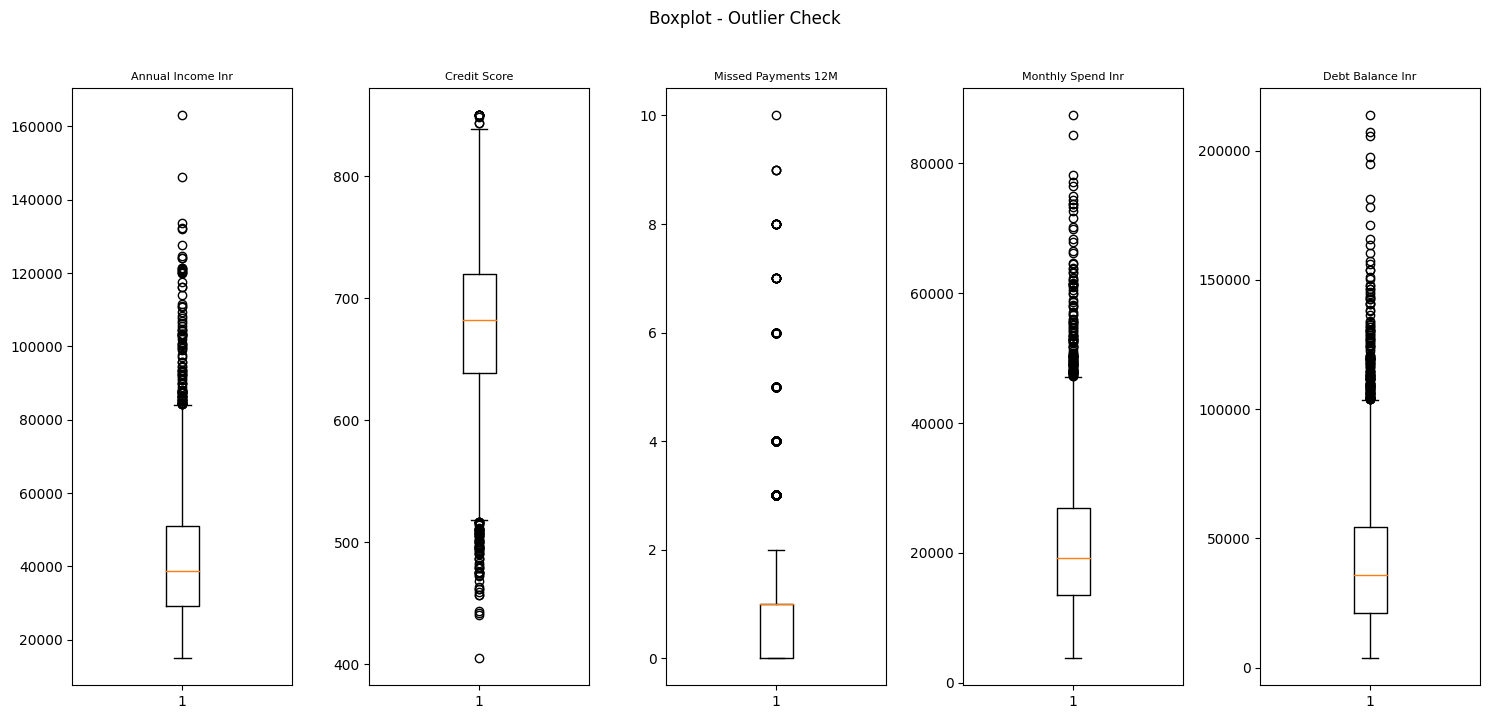

In [22]:
outlier_cols = ['annual_income_inr', 'credit_score', 'missed_payments_12m', 'monthly_spend_inr', 'debt_balance_inr']

plt.figure(figsize=(15, 7))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 5, i)
    plt.boxplot(X[col].dropna())
    plt.title(col.replace('_', ' ').title(), fontsize=8)
    plt.tight_layout()

plt.suptitle("Boxplot - Outlier Check", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

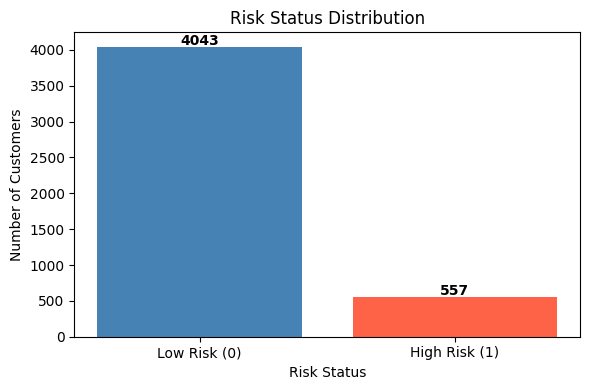

In [23]:
labels = ['Low Risk (0)', 'High Risk (1)']
counts = y.value_counts().sort_index().values

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['steelblue', 'tomato'])
plt.title("Risk Status Distribution")
plt.xlabel("Risk Status")
plt.ylabel("Number of Customers")
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

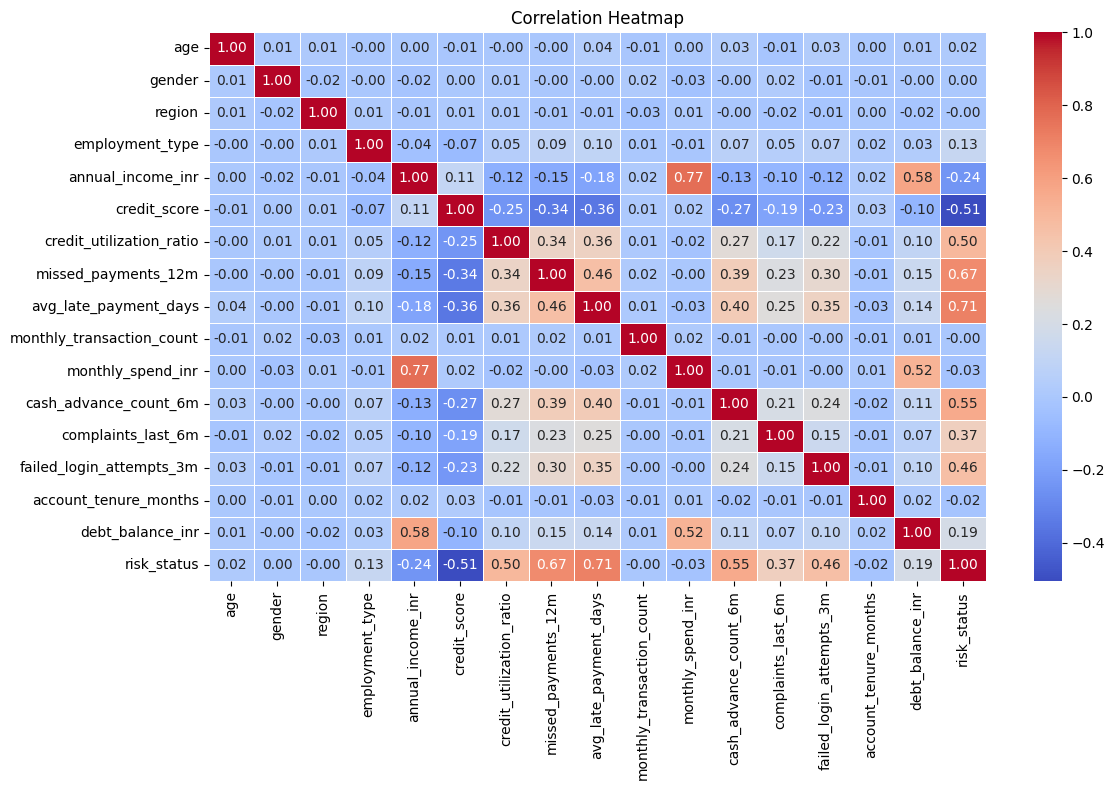

In [24]:
combined = X.copy()
combined['risk_status'] = y.values

plt.figure(figsize=(12, 8))
corr = combined.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

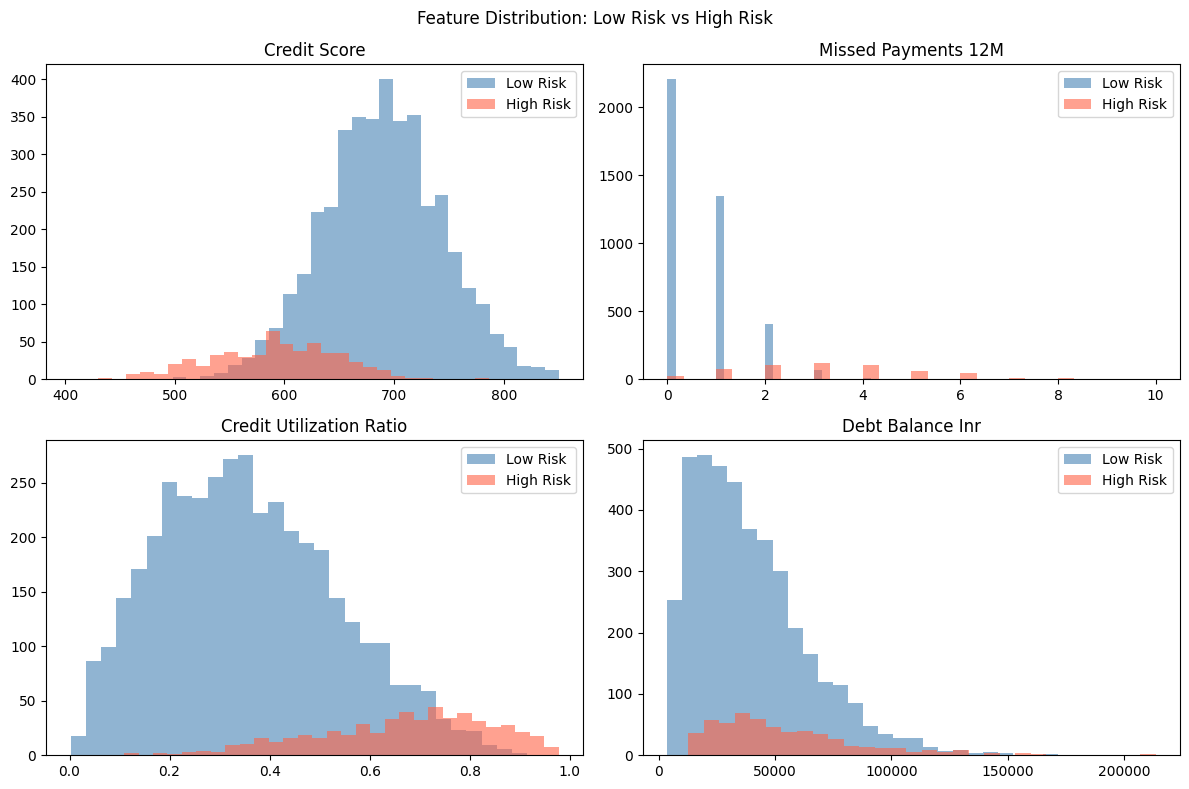

In [25]:
key_features = ['credit_score', 'missed_payments_12m', 'credit_utilization_ratio', 'debt_balance_inr']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    low_risk = X[col][y == 0]
    high_risk = X[col][y == 1]
    axes[i].hist(low_risk, bins=30, alpha=0.6, label='Low Risk', color='steelblue')
    axes[i].hist(high_risk, bins=30, alpha=0.6, label='High Risk', color='tomato')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend()
plt.suptitle("Feature Distribution: Low Risk vs High Risk", fontsize=12)
plt.tight_layout()
plt.show()

# Data Preprocessing - Feature Scaling

In [27]:
scaler = StandardScaler()   # Apply Standard Scaler to normalize feature values
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [28]:
X_scaled.head(2)

,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr
0,0.632715,-1.026849,0.63120,-0.609911,2.305858,-0.155167,-1.351428,0.058367,-0.593622,-1.076593,1.151539,-0.695595,2.172492,1.179790,0.518979,1.730145
1,-0.696483,-1.026849,-1.58692,-0.609911,-0.508628,-0.481340,-0.283696,0.058367,-0.718082,-2.234664,-0.983645,0.284416,0.776757,-0.670545,-0.630375,-0.770500


In [29]:
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

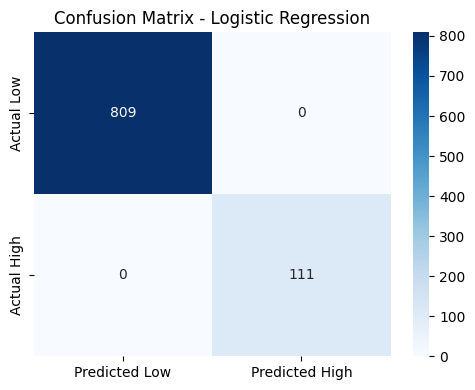

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Low', 'Predicted High'], yticklabels=['Actual Low', 'Actual High'])
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [32]:
print("Logistic Regression Performance: ")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]):.4f}")

Logistic Regression Performance: 
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
AUC-ROC   : 1.0000


# Handling Imbalancedd Data

In [34]:
imbalance_results = {}

def evaluate_model(y_true, y_pred, y_prob, name):
    results = {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4)
    }
    return results

# Baseline result 
prob_lr = lr_model.predict_proba(X_test)[:, 1]
imbalance_results['Original'] = evaluate_model(y_test, y_pred_lr, prob_lr, 'Original')

In [35]:
# Under-Sampling 
under = RandomUnderSampler(random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)
print("Under-sampled class distribution:", dict(zip(*np.unique(y_under, return_counts=True))))

lr_under = LogisticRegression(random_state=42, max_iter=1000)
lr_under.fit(X_under, y_under)
y_pred_under = lr_under.predict(X_test)
prob_under = lr_under.predict_proba(X_test)[:, 1]
imbalance_results['Under-Sampling'] = evaluate_model(y_test, y_pred_under, prob_under, 'Under')

Under-sampled class distribution: {0.0: 446, 1.0: 446}


In [36]:
# Over-Sampling
over = RandomOverSampler(random_state=42)
X_over, y_over = over.fit_resample(X_train, y_train)
print("Over-sampled class distribution:", dict(zip(*np.unique(y_over, return_counts=True))))

lr_over = LogisticRegression(random_state=42, max_iter=1000)
lr_over.fit(X_over, y_over)
y_pred_over = lr_over.predict(X_test)
prob_over = lr_over.predict_proba(X_test)[:, 1]
imbalance_results['Over-Sampling'] = evaluate_model(y_test, y_pred_over, prob_over, 'Over')

Over-sampled class distribution: {0.0: 3234, 1.0: 3234}


In [37]:
# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("SMOTE class distribution:", dict(zip(*np.unique(y_smote, return_counts=True))))

lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_smote, y_smote)
y_pred_smote = lr_smote.predict(X_test)
prob_smote = lr_smote.predict_proba(X_test)[:, 1]
imbalance_results['SMOTE'] = evaluate_model(y_test, y_pred_smote, prob_smote, 'SMOTE')

SMOTE class distribution: {0.0: 3234, 1.0: 3234}


In [38]:
# ADASYN
adasyn = ADASYN(random_state=42)
X_ada, y_ada = adasyn.fit_resample(X_train, y_train)
print("ADASYN class distribution:", dict(zip(*np.unique(y_ada, return_counts=True))))

lr_ada = LogisticRegression(random_state=42, max_iter=1000)
lr_ada.fit(X_ada, y_ada)
y_pred_ada = lr_ada.predict(X_test)
prob_ada = lr_ada.predict_proba(X_test)[:, 1]
imbalance_results['ADASYN'] = evaluate_model(y_test, y_pred_ada, prob_ada, 'ADASYN')

ADASYN class distribution: {0.0: 3234, 1.0: 3251}


In [39]:
imbalance_df = pd.DataFrame(imbalance_results).T
print("Comparison: Before and After Balancing (Logistic Regression): ")
print()
print(imbalance_df)

Comparison: Before and After Balancing (Logistic Regression): 

                Accuracy  Precision  Recall  F1-Score  AUC-ROC
Original          1.0000     1.0000     1.0    1.0000      1.0
Under-Sampling    0.9957     0.9652     1.0    0.9823      1.0
Over-Sampling     0.9967     0.9737     1.0    0.9867      1.0
SMOTE             0.9967     0.9737     1.0    0.9867      1.0
ADASYN            0.9935     0.9487     1.0    0.9737      1.0


# Tree Based Classification Models 

In [41]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_smote, y_smote)

y_pred_dt_train = dt_model.predict(X_smote)
y_pred_dt_test  = dt_model.predict(X_test)

# Check for overfitting
print("Decision Tree: Overfitting Check : ")
print(f"Training Accuracy: {accuracy_score(y_smote, y_pred_dt_train):.4f}")
print(f"Testing  Accuracy: {accuracy_score(y_test,  y_pred_dt_test):.4f}")

Decision Tree: Overfitting Check : 
Training Accuracy: 1.0000
Testing  Accuracy: 0.9717


In [42]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_smote, y_smote)

y_pred_rf_train = rf_model.predict(X_smote)
y_pred_rf_test  = rf_model.predict(X_test)

print("Random Forest: Overfitting Check : ")
print(f"Training Accuracy: {accuracy_score(y_smote, y_pred_rf_train):.4f}")
print(f"Testing  Accuracy: {accuracy_score(y_test,  y_pred_rf_test):.4f}")

Random Forest: Overfitting Check : 
Training Accuracy: 1.0000
Testing  Accuracy: 0.9967


In [43]:
# Compare Decision Tree vs Random Forest
print("Decision Tree vs Random Forest (Test Set) : ")
print()
print(f"{'Metric':<15} {'Decision Tree':>15} {'Random Forest':>15}")
for metric, func in [('Accuracy', accuracy_score), ('Precision', precision_score),('Recall', recall_score), ('F1-Score', f1_score)]:
    kwargs = {} if metric == 'Accuracy' else {'zero_division': 0}
    dt_val = func(y_test, y_pred_dt_test, **kwargs)
    rf_val = func(y_test, y_pred_rf_test, **kwargs)
    print(f"{metric:<15} {dt_val:>15.4f} {rf_val:>15.4f}")

Decision Tree vs Random Forest (Test Set) : 

Metric            Decision Tree   Random Forest
Accuracy                 0.9717          0.9967
Precision                0.8455          0.9909
Recall                   0.9369          0.9820
F1-Score                 0.8889          0.9864


# Hyperparameter tunning

In [45]:
# Randomized Search CV for Decision Tree
dt_param_dist = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=20, cv=5, scoring='recall', random_state=42, n_jobs=-1
)
dt_random.fit(X_smote, y_smote)
print("Best DT params: ", dt_random.best_params_)

Best DT params:  {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'gini'}


In [46]:
# Randomized Search CV for Random Forest
rf_param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20, cv=5, scoring='recall', random_state=42, n_jobs=-1
)
rf_random.fit(X_smote, y_smote)
print("Best RF params: ", rf_random.best_params_)

Best RF params:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


In [47]:
best_rf_params = rf_random.best_params_

rf_grid_params = {
    'n_estimators': [best_rf_params['n_estimators'] - 50, best_rf_params['n_estimators'], best_rf_params['n_estimators'] + 50],
    'max_depth': [best_rf_params['max_depth']], 'min_samples_split': [best_rf_params['min_samples_split']],
    'min_samples_leaf': [best_rf_params['min_samples_leaf']]}

rf_grid_params['n_estimators'] = [n for n in rf_grid_params['n_estimators'] if n and n > 0]

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_grid_params,
    cv=5, scoring='recall', n_jobs=-1
)
rf_grid.fit(X_smote, y_smote)
print("Best RF params: ", rf_grid.best_params_)

Best RF params:  {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [48]:
# Train the final tuned Random Forest model
rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("Tuned vs Untuned Random Forest: ")
print(f"{'Metric':<15} {'Untuned RF':>12} {'Tuned RF':>12}")
print("-" * 40)
for metric, func in [('Accuracy', accuracy_score), ('Precision', precision_score), ('Recall', recall_score), ('F1-Score', f1_score)]:
    kwargs = {} if metric == 'Accuracy' else {'zero_division': 0}
    untuned = func(y_test, y_pred_rf_test, **kwargs)
    tuned   = func(y_test, y_pred_rf_tuned, **kwargs)
    print(f"{metric:<15} {untuned:>12.4f} {tuned:>12.4f}")

Tuned vs Untuned Random Forest: 
Metric            Untuned RF     Tuned RF
----------------------------------------
Accuracy              0.9967       0.9957
Precision             0.9909       0.9820
Recall                0.9820       0.9820
F1-Score              0.9864       0.9820


# Model Evaluation and ROC Analysis

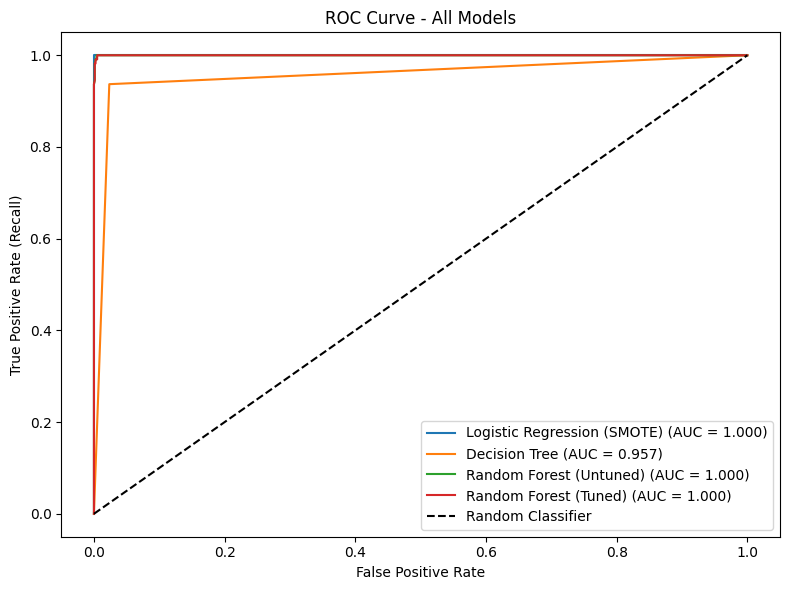

In [50]:
models_for_roc = {
    'Logistic Regression (SMOTE)': (y_pred_smote, prob_smote),
    'Decision Tree': (y_pred_dt_test, dt_model.predict_proba(X_test)[:, 1]),
    'Random Forest (Untuned)': (y_pred_rf_test, rf_model.predict_proba(X_test)[:, 1]),
    'Random Forest (Tuned)': (y_pred_rf_tuned, prob_rf_tuned),
}

plt.figure(figsize=(8, 6))

for name, (y_pred, y_prob) in models_for_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - All Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [51]:
print("AUC-ROC Scores")
for name ,(y_pred,y_prob) in models_for_roc.items():
    auc = roc_auc_score(y_test,y_prob)
    print(f"{name:<35}: {auc:.4f}")

AUC-ROC Scores
Logistic Regression (SMOTE)        : 1.0000
Decision Tree                      : 0.9567
Random Forest (Untuned)            : 0.9999
Random Forest (Tuned)              : 0.9999


In [52]:
all_results = {}

for name ,(y_pred,y_prob) in models_for_roc.items():
    all_results[name] = {
        'Accuracy': round(accuracy_score(y_test,y_pred),4),
        'Precision': round(precision_score(y_test,y_pred,zero_division=0),4),
        'Recall': round(recall_score(y_test,y_pred),4),
        'F1-Score': round(f1_score(y_test,y_pred,zero_division=0),4),
        'AUC-ROC': round(roc_auc_score(y_test,y_prob),4)
    }
results_df = pd.DataFrame(all_results).T
print('Complete Model Comparison')
print(results_df)

Complete Model Comparison
                             Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression (SMOTE)    0.9967     0.9737  1.0000    0.9867   1.0000
Decision Tree                  0.9717     0.8455  0.9369    0.8889   0.9567
Random Forest (Untuned)        0.9967     0.9909  0.9820    0.9864   0.9999
Random Forest (Tuned)          0.9957     0.9820  0.9820    0.9820   0.9999


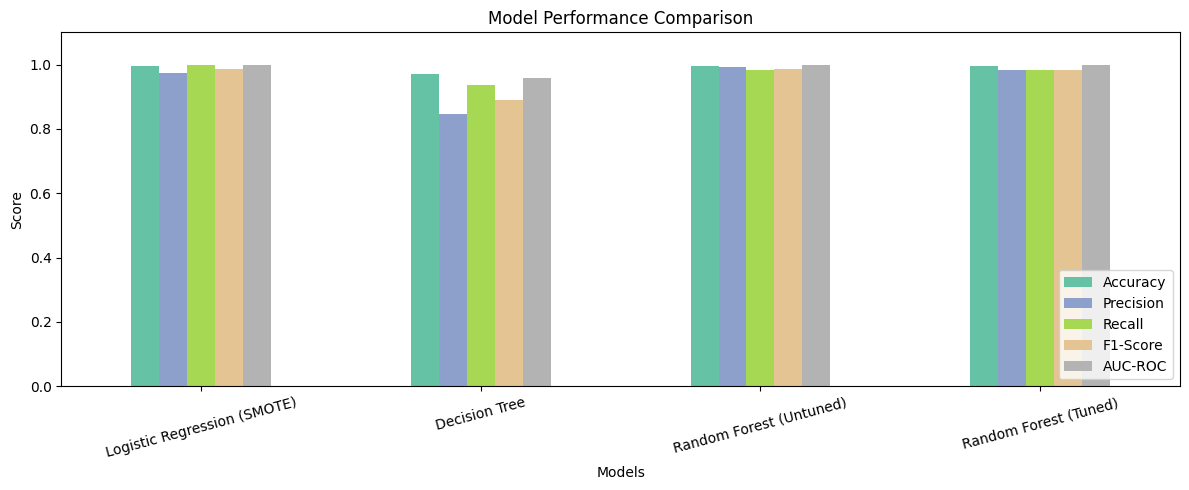

In [53]:
results_df.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [54]:
print("Selecting best model besed on Recall (most imporatnat fot fraud detection)...")
best_mmodel_name = results_df['Recall'].idxmax()
print('Best model:' + best_mmodel_name)
print()
print('Best model scores:')
print(results_df.loc[best_mmodel_name])

Selecting best model besed on Recall (most imporatnat fot fraud detection)...
Best model:Logistic Regression (SMOTE)

Best model scores:
Accuracy     0.9967
Precision    0.9737
Recall       1.0000
F1-Score     0.9867
AUC-ROC      1.0000
Name: Logistic Regression (SMOTE), dtype: float64


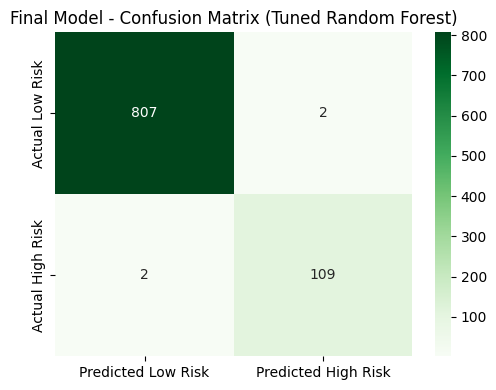

In [55]:
final_model = rf_tuned
y_final_pred = y_pred_rf_tuned

cm_final = confusion_matrix(y_test,y_final_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_final,annot=True,fmt='d',cmap='Greens',xticklabels=['Predicted Low Risk','Predicted High Risk'],yticklabels=['Actual Low Risk','Actual High Risk'])
plt.title("Final Model - Confusion Matrix (Tuned Random Forest)")
plt.tight_layout()
plt.show()

In [56]:
test_sample = X_test.head(20)
sample_predictions = final_model.predict(test_sample)
sample_actual = y_test.head(20).values

print("Sample Predictions vs Actual Values: ")
pred_df = pd.DataFrame({
    'Actual Risk Status': sample_actual,
    'Predicted Risk Status': sample_predictions,
    'Match': ['Correct' if a == p else 'Wrong' for a, p in zip(sample_actual, sample_predictions)]})
print(pred_df.to_string(index=False))

Sample Predictions vs Actual Values: 
 Actual Risk Status  Predicted Risk Status   Match
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                0.0                    0.0 Correct
                1.0                    1.0 C

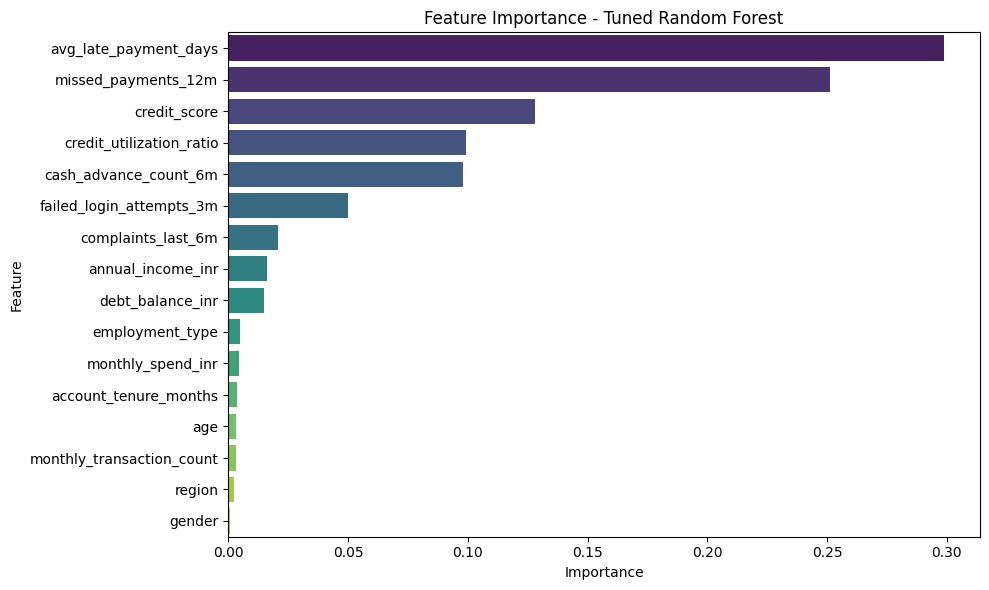

Top 5 Most Important Features:
                 Feature  Importance
   avg_late_payment_days    0.298865
     missed_payments_12m    0.251339
            credit_score    0.127919
credit_utilization_ratio    0.099170
   cash_advance_count_6m    0.098027


In [57]:
importance_df = pd.DataFrame({ 'Feature': X.columns,'Importance': final_model.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance - Tuned Random Forest")
plt.tight_layout()
plt.show()
print("Top 5 Most Important Features:")
print(importance_df.head(5).to_string(index=False))

# **Conclusion**
- This project successfully developed a machine learning model to classify individuals into different risk levels based on financial and behavioral data. After applying data preprocessing, feature scaling, and class imbalance techniques such as SMOTE, the model achieved excellent performance. Among all the evaluated models, Logistic Regression with SMOTE delivered the best results, achieving 99.67% accuracy, 100% recall, and an AUC-ROC score of 1.00. The results demonstrate that proper preprocessing and imbalance handling significantly improve prediction performance, making the model reliable for risk classification tasks.